# DisasterTweets — EDA

Kaggle `nlp-getting-started`: binary text classification (real disaster vs not), metric **F1**.
Findings are written up in [`reports/EDA_FINDINGS.md`](../reports/EDA_FINDINGS.md); figures in `reports/figures/`.

In [1]:
import os, re
os.chdir(os.path.dirname(os.getcwd())) if os.path.basename(os.getcwd()) == 'notebooks' else None
from pathlib import Path
import pandas as pd, matplotlib.pyplot as plt
from src import data
FIG = Path('reports/figures'); FIG.mkdir(parents=True, exist_ok=True)
tr, te = data.load_train(), data.load_test()
print('train', tr.shape, 'test', te.shape)
tr.head()

train (7613, 5) test (3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


## Class balance & missingness

balance: {0: 0.5703, 1: 0.4297}
missing train: {'id': 0, 'keyword': 61, 'location': 2533, 'text': 0, 'target': 0}
missing test : {'id': 0, 'keyword': 26, 'location': 1105, 'text': 0}


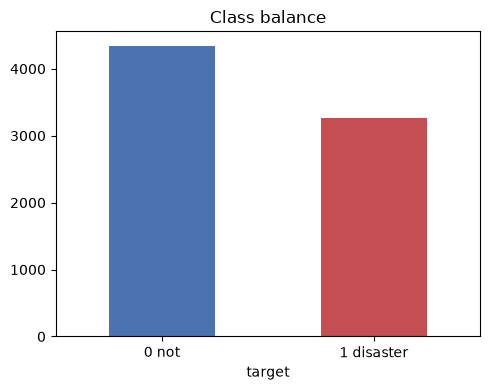

In [2]:
print('balance:', tr[data.TARGET].value_counts(normalize=True).round(4).to_dict())
print('missing train:', tr.isna().sum().to_dict())
print('missing test :', te.isna().sum().to_dict())
fig, ax = plt.subplots(figsize=(5,4))
tr[data.TARGET].value_counts().sort_index().plot(kind='bar', ax=ax, color=['#4c72b0','#c44e52'])
ax.set_title('Class balance'); ax.set_xticklabels(['0 not','1 disaster'], rotation=0)
fig.tight_layout(); fig.savefig(FIG/'class_balance.png', dpi=110); plt.show()

## Text statistics by class

target,0,1
char_len,95.71,108.11
word_len,14.70,15.17
n_url,0.51,0.77
n_mention,0.42,0.27
n_hashtag,0.39,0.50
n_exclaim,0.19,0.10


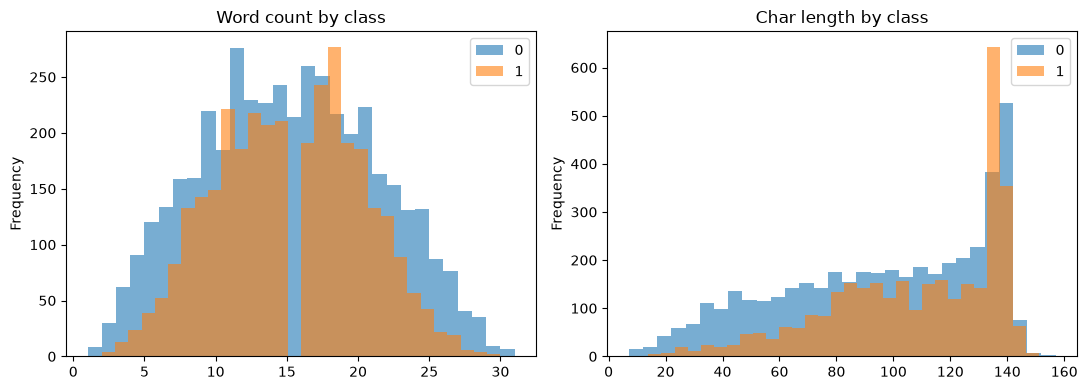

In [3]:
URL = re.compile(r'https?://\S+|www\.\S+'); MENTION = re.compile(r'@\w+'); HASHTAG = re.compile(r'#\w+')
def feats(df):
    t = df[data.TEXT_COL].astype(str)
    return pd.DataFrame({'char_len': t.str.len(), 'word_len': t.str.split().apply(len),
        'n_url': t.apply(lambda s: len(URL.findall(s))), 'n_mention': t.apply(lambda s: len(MENTION.findall(s))),
        'n_hashtag': t.apply(lambda s: len(HASHTAG.findall(s))), 'n_exclaim': t.str.count('!')})
ftr = feats(tr); ftr[data.TARGET] = tr[data.TARGET].values
display(ftr.groupby(data.TARGET).mean().round(2).T)
fig, ax = plt.subplots(1,2, figsize=(11,4))
ftr.groupby(data.TARGET)['word_len'].plot(kind='hist', bins=30, alpha=0.6, ax=ax[0], legend=True); ax[0].set_title('Word count by class')
ftr.groupby(data.TARGET)['char_len'].plot(kind='hist', bins=30, alpha=0.6, ax=ax[1], legend=True); ax[1].set_title('Char length by class')
fig.tight_layout(); fig.savefig(FIG/'text_length_by_class.png', dpi=110); plt.show()

## Keyword disaster rate (highly predictive)

most disaster-y:


,mean,count
keyword,,
suicide%20bomber,0.968,31
suicide%20bombing,0.970,33
typhoon,0.974,38
oil%20spill,0.974,38
outbreak,0.975,40
debris,1.000,37
wreckage,1.000,39
derailment,1.000,39


least disaster-y:


,mean,count
keyword,,
aftershock,0.000,34
body%20bags,0.024,41
ruin,0.027,37
blazing,0.029,34
body%20bag,0.030,33
electrocute,0.031,32
screaming,0.056,36
traumatised,0.057,35


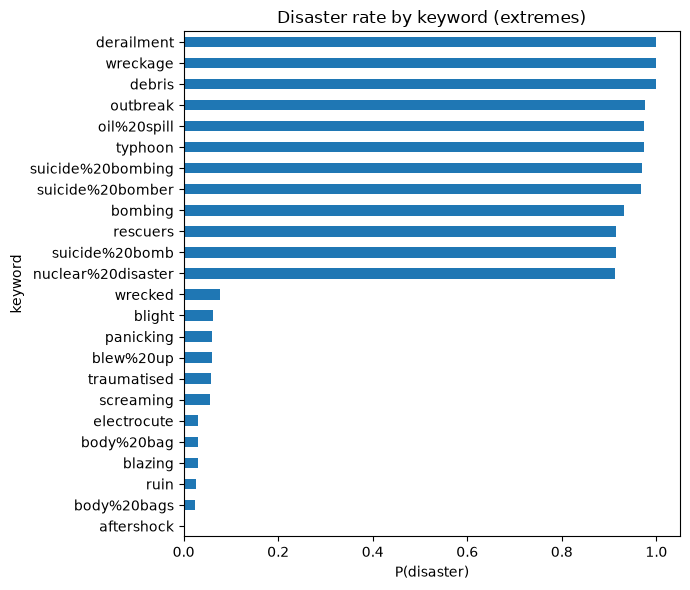

In [4]:
kw = tr.dropna(subset=[data.KEYWORD_COL]).groupby(data.KEYWORD_COL)[data.TARGET].agg(['mean','count'])
kw = kw[kw['count'] >= 25].sort_values('mean')
print('most disaster-y:'); display(kw.tail(8).round(3))
print('least disaster-y:'); display(kw.head(8).round(3))
fig, ax = plt.subplots(figsize=(7,6))
pd.concat([kw.head(12), kw.tail(12)])['mean'].plot(kind='barh', ax=ax)
ax.set_title('Disaster rate by keyword (extremes)'); ax.set_xlabel('P(disaster)')
fig.tight_layout(); fig.savefig(FIG/'keyword_disaster_rate.png', dpi=110); plt.show()

## Data-quality: duplicate-label conflicts & train/test overlap

In [5]:
dup = tr.groupby(data.TEXT_COL)[data.TARGET].agg(['nunique','count'])
conflict = dup[dup['nunique'] > 1]
print(f'duplicate-text groups: {(dup["count"]>1).sum()}')
print(f'conflicting-label groups: {len(conflict)} ({int(conflict["count"].sum())} rows)')
overlap = set(tr[data.TEXT_COL]) & set(te[data.TEXT_COL])
print(f'train/test verbatim-text overlap: {len(overlap)} tweets')
vtr = set(' '.join(tr[data.TEXT_COL].str.lower()).split()); vte = set(' '.join(te[data.TEXT_COL].str.lower()).split())
print(f'test tokens unseen in train: {len(vte-vtr)} ({len(vte-vtr)/len(vte):.1%})')

duplicate-text groups: 69
conflicting-label groups: 18 (55 rows)
train/test verbatim-text overlap: 68 tweets
test tokens unseen in train: 8630 (56.3%)
